In [ ]:
import sys
sys.path.insert(0, '..')
from dependencies import *

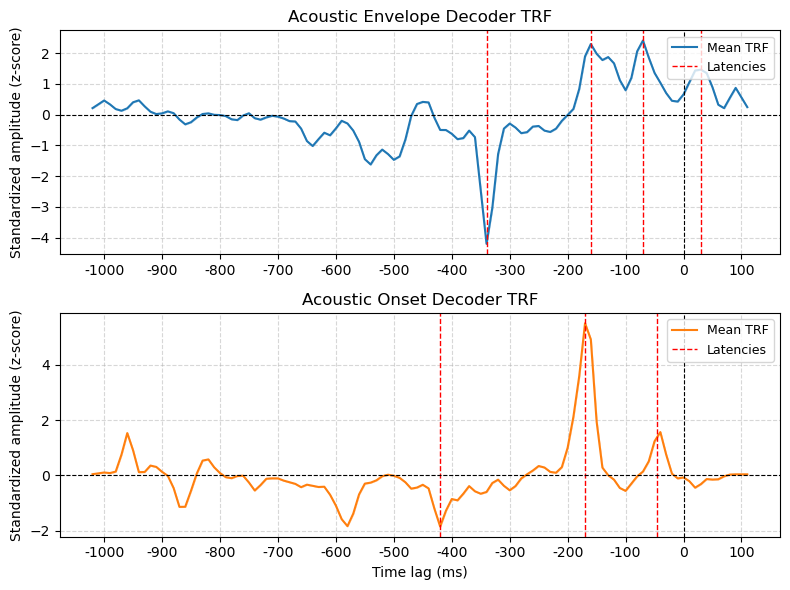

In [3]:
# ------------------------------------------------
# Load universal decoder TRFs
# ------------------------------------------------
decoder_trfs = {
    'log': eelbrain.load.unpickle(TRF_DIR / 'decoder-universal-trf-envelope_log.pickle'),
    'onset': eelbrain.load.unpickle(TRF_DIR / 'decoder-universal-trf-envelope_onset.pickle')
}

# ------------------------------------------------
# DEFINE LATENCIES (in seconds) PER MODEL
# ------------------------------------------------
latencies_dict = {
    'log':   [-0.070, -0.160, -0.340, 0.030],   # Envelope TRF latencies
    'onset': [-0.045, -0.170, -0.420]           # Onset TRF latencies
}

# ------------------------------------------------
# Prepare figure
# ------------------------------------------------
fig, axes = plt.subplots(2, 1, figsize=(8, 6), sharex=True)

colors = {'log': 'tab:blue', 'onset': 'tab:orange'}

# ------------------------------------------------
# Plot loop
# ------------------------------------------------
for i, model in enumerate(['log', 'onset']):
    trf = decoder_trfs[model]

    # Average predictors if present
    if 'predictor' in trf.dims:
        trf_plot = trf.mean('predictor')
        trf_std = trf.std('predictor')
        if hasattr(trf_std, '__array__'):
            trf_std = np.array(trf_std)
    else:
        trf_plot = trf
        trf_std = np.zeros_like(trf_plot.x)

    # ----------------------------------------
    # Convert time to milliseconds
    # ----------------------------------------
    time_ms = np.array(trf_plot.time) * 1000  # <- FIXED

    # ----------------------------------------
    # Standardize
    # ----------------------------------------
    y = (trf_plot.x - np.mean(trf_plot.x)) / np.std(trf_plot.x)
    y_std = trf_std / np.std(trf_plot.x)

    # ----------------------------------------
    # Plot mean TRF
    # ----------------------------------------
    axes[i].plot(time_ms, y, color=colors[model], label='Mean TRF')

    # ----------------------------------------
    # Shaded ±1 SD
    # ----------------------------------------
    axes[i].fill_between(
        time_ms,
        y - y_std,
        y + y_std,
        color=colors[model],
        alpha=0.2
    )

    # ----------------------------------------
    # Vertical latency lines (MODEL-SPECIFIC)
    # ----------------------------------------
    latencies = latencies_dict[model]

    for j, t in enumerate(latencies):
        if j == 0:
            axes[i].axvline(t * 1000, color='red', linestyle='--', linewidth=1, label='Latencies')
        else:
            axes[i].axvline(t * 1000, color='red', linestyle='--', linewidth=1)

    # ----------------------------------------
    # Formatting
    # ----------------------------------------
    type_model = 'Acoustic Envelope' if model == 'log' else 'Acoustic Onset'

    axes[i].set_title(type_model + ' Decoder TRF')
    axes[i].set_ylabel('Standardized amplitude (z-score)')
    axes[i].axhline(0, linestyle='--', color='black', linewidth=0.8)
    axes[i].axvline(0, linestyle='--', color='black', linewidth=0.8)
    axes[i].grid(True, linestyle='--', alpha=0.5)
    axes[i].legend(loc='upper right', fontsize=9)

    # Force x-axis ticks for both plots
    axes[i].xaxis.set_major_locator(MultipleLocator(100))  # every 100 ms
    axes[i].xaxis.set_major_formatter(FormatStrFormatter('%d'))
    axes[i].tick_params(axis='x', labelbottom=True)

# Shared x-axis label
axes[-1].set_xlabel('Time lag (ms)')

plt.tight_layout()
plt.show()

